In [1]:
from prysm.interferogram import (
    abc_psd,
    render_synthetic_surface
)

from prysm.coordinates import make_xy_grid, cart_to_polar
from prysm.propagation import focus_fixed_sampling
from prysm.geometry import circle
from prysm.x.dm import DM

from poi.influence_funcs import gaussian_influence_function

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import Circle

# Set up a PSD wavefront error

In [2]:
nu = np.arange(1,1000,1)

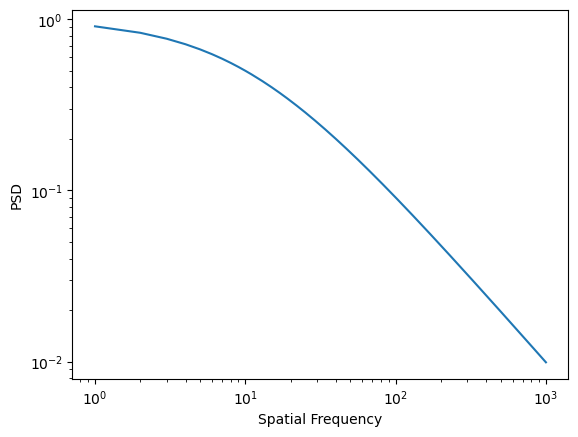

In [3]:
psd = abc_psd(nu, a=1, b=10, c=1)

plt.figure()
plt.plot(nu, psd)
plt.xscale('log')
plt.yscale('log')
plt.ylabel('PSD')
plt.xlabel('Spatial Frequency')
plt.show()

In [4]:
# Just picked ABC values until it looked about right
Npup = 256
x, y, z = render_synthetic_surface(10, Npup, a=5e4, b=1/1000, c=3)

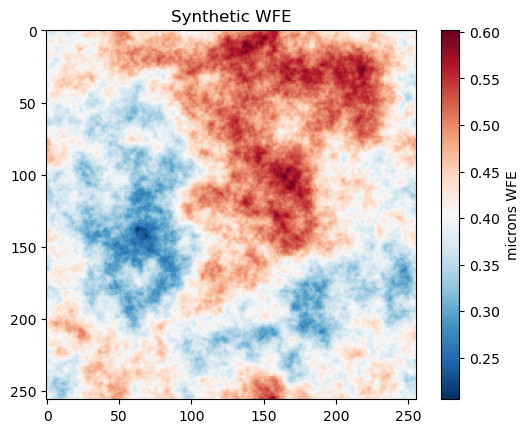

In [5]:
plt.figure()
plt.title('Synthetic WFE')
plt.imshow(z, cmap='RdBu_r')
plt.colorbar(label='microns WFE')
plt.show()

# 2. Set up a diffraction model

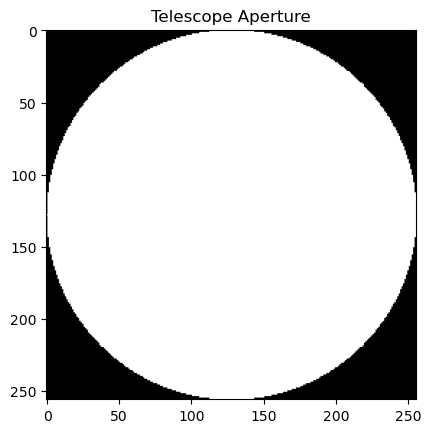

In [6]:
x, y = make_xy_grid(Npup, diameter=2)
r, t = cart_to_polar(x, y)
A = circle(1, r)
plt.figure()
plt.imshow(A, cmap='gray')
plt.title('Telescope Aperture')
plt.show()

In [7]:
# create pupil function and propagate
WVL = 1 # micron
EFL = 100 # mm
Dpup = 10 # mm
dx_img = 1 # microns
wvfnt = A * np.exp(1j * 2 * np.pi / WVL * z) # with error

focal = focus_fixed_sampling(wvfnt,
                             input_dx=Dpup / wvfnt.shape[0], # mm pupil
                             prop_dist=EFL, # mm focal length
                             wavelength=WVL, # microns
                             output_dx=dx_img, # microns
                             output_samples=wvfnt.shape[0])

focal_intensity = np.abs(focal)**2

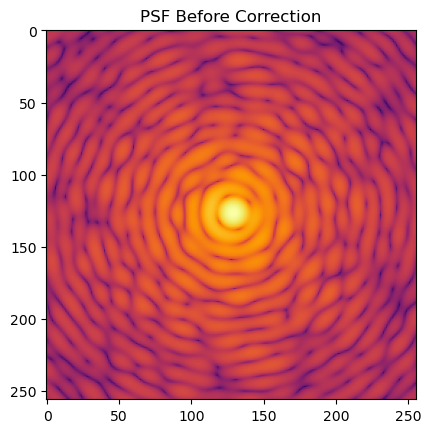

In [8]:
plt.title('PSF Before Correction')
plt.imshow(focal_intensity, cmap='inferno', norm=LogNorm())

In [9]:
# create a dark hole
um_to_LD = 1e-6 / (EFL * 1e-3) * (Dpup * 1e-3) / (WVL * 1e-6)
print(um_to_LD)
u, v = make_xy_grid(focal.shape, dx=dx_img * um_to_LD)
rho, psi = cart_to_polar(u, v)

dark_hole = np.zeros_like(u)
dark_hole[rho < 7] = 1
dark_hole[rho < 4] = 0
dark_hole[u < 3] = 0

0.1


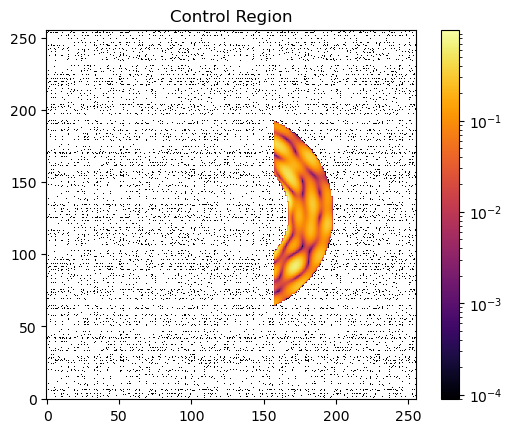

In [10]:
masked_intensity = dark_hole * focal_intensity
plt.title('Control Region')
plt.imshow(masked_intensity, cmap='inferno', norm=LogNorm(), origin='lower')

plt.colorbar()

In [11]:
yind, xind = np.unravel_index(np.argmax(masked_intensity), masked_intensity.shape)

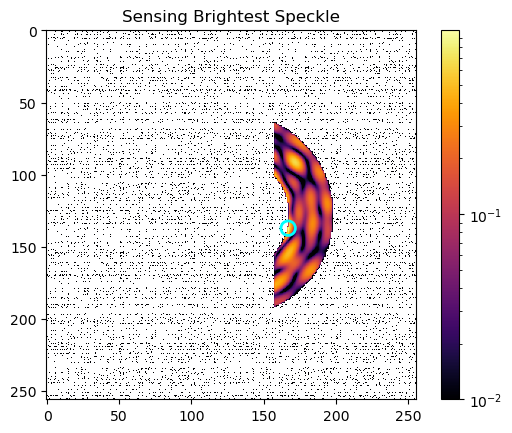

In [12]:
fig, ax = plt.subplots()
plt.title('Sensing Brightest Speckle')
im = ax.imshow(masked_intensity, cmap='inferno', norm=LogNorm(vmin=1e-2))
fig.colorbar(im)

circ = Circle((xind, yind), radius=5, color='cyan', fill=False, linewidth=2)
ax.add_patch(circ)
plt.show()


In [13]:
# Set up DM
nact = 34 # number of actuators
act_pitch = 0.5 # mm?
samples_per_act = 7 # chosen to over-fill illuminated aperture
sampling_pitch = act_pitch / samples_per_act

xdm, ydm = make_xy_grid(Npup, dx=sampling_pitch)
rhodm, _ = cart_to_polar(xdm, ydm)
influence_func = gaussian_influence_function(rho, sampling_pitch)

$$\frac{0.5 mm}{1 actuator} \circ \frac{1 actuator}{7 samples}$$

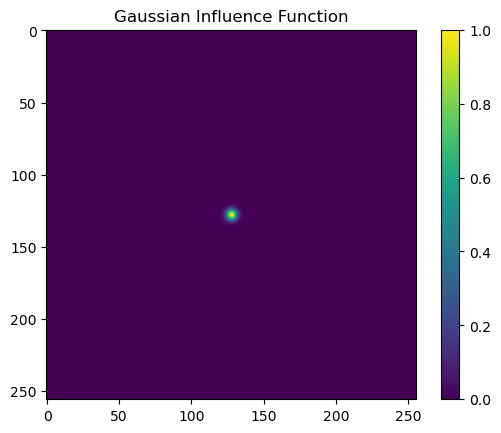

In [14]:
plt.title("Gaussian Influence Function")
plt.imshow(influence_func)
plt.colorbar()
plt.show()

In [15]:
dm = DM(influence_func, Nout=Npup, Nact=nact, sep=samples_per_act)

# Uncertain how to relate DM Frequency to pixel location

We know from _triangles_ that the relation of the diffracted angle ($\theta$) to some position ($h$) is given by god's equation

$$h' = f'tan(\theta)$$

Alternatively

$$\theta = tan^{-1}(\frac{h'}{f})$$

From the equation for sinusoidal gratings, we have a similar relation of grating frequency ($\eta$), and wavelength ($\lambda$), to diffracted angle

$$\lambda \eta = sin(\theta)$$

Putting these equations together we can derive an expression for the required grating frequency

$$\eta = \frac{sin(tan^{-1}(\frac{h'}{f}))}{\lambda} \approx \frac{h'}{f \lambda}$$

Note the importance of keeping the units consistent across these

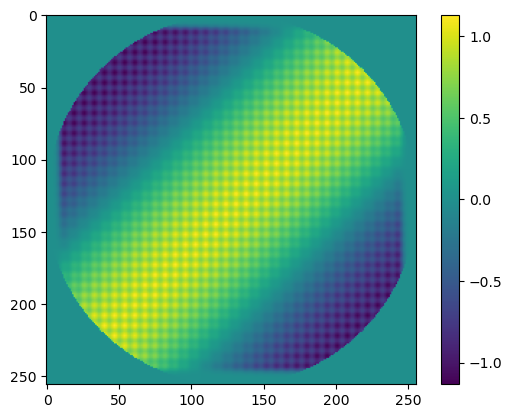

In [16]:
# Creating a fourier mode
xact, yact = make_xy_grid(nact, dx=act_pitch)

xfreq = 1
yfreq = 1
aberration = np.cos(xact*xfreq/4 + yact*yfreq/4)
dm.actuators[:] = aberration
plt.imshow(dm.render(wfe=None) * A)
plt.colorbar()

In [17]:
tilt_wfe = A * np.exp(1j * dm.render(wfe=True)/4)

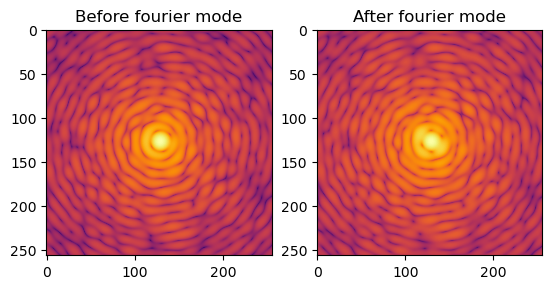

In [18]:
def fwd(pupil_wfe=np.ones_like(wvfnt)):
    focal = focus_fixed_sampling(wvfnt * pupil_wfe,
                                input_dx=Dpup / wvfnt.shape[0], # mm pupil
                                prop_dist=EFL, # mm focal length
                                wavelength=WVL, # microns
                                output_dx=dx_img, # microns
                                output_samples=wvfnt.shape[0])
    return focal

focal_nominal = fwd()
focal_cosine = fwd(tilt_wfe)
plt.figure()
plt.subplot(121)
plt.title('Before fourier mode')
plt.imshow(np.abs(focal_nominal)**2, norm=LogNorm(), cmap='inferno')
plt.subplot(122)
plt.title('After fourier mode')
plt.imshow(np.abs(focal_cosine)**2, norm=LogNorm(), cmap='inferno')
plt.show()

# Intentionally try to Null Speckle

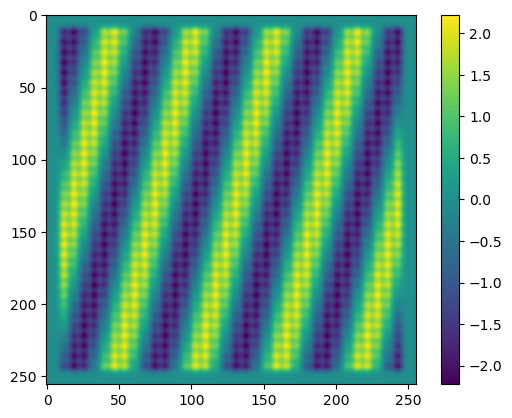

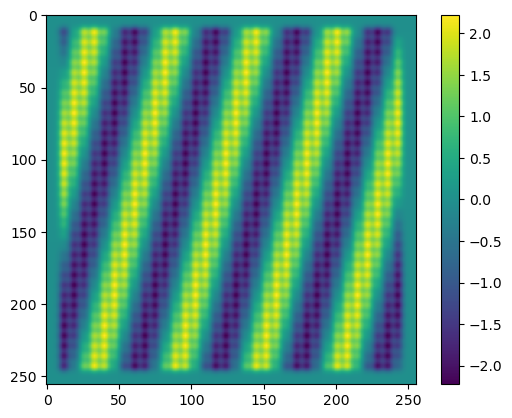

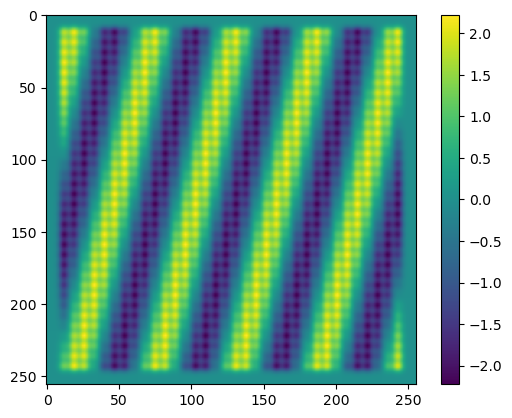

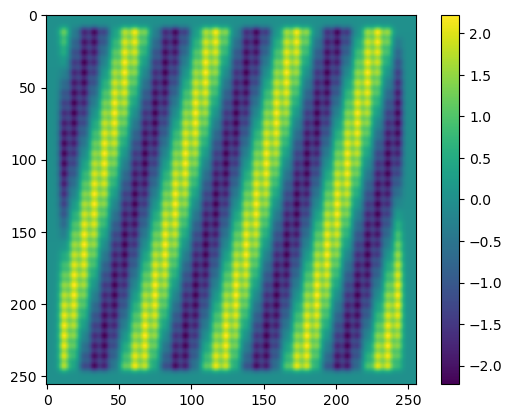

In [19]:
# Get x,y index of the masked intensity
yind, xind = np.unravel_index(np.argmax(masked_intensity), masked_intensity.shape)

# compute fourier mnode corresponding to location, here is a grid in um
# ximg, yimg = make_xy_grid(shape=masked_intensity.shape, dx=dx_img)

# # get in angle units, EFL is in mm
# ximg /= (EFL * 1e3)
# yimg /= (EFL * 1e3)

# # divide by wavelength to get frequency units, WVL in microns
# ximg /= (WVL)
# yimg /= (WVL)

## This is an image position in radians
yfreq = u[xind, yind] * (Dpup / WVL) / EFL
xfreq = v[xind, yind] * (Dpup / WVL) / EFL


# drop a speckle
phase_shift = np.arange(0, 2*np.pi, np.pi/2)
sensed_imgs = []

for p in phase_shift:

    # apply phase shift to fourier mode8
    aberration = np.cos(xact*xfreq*4 + yact*yfreq*4 + p)
    dm.actuators[:] = aberration

    # create aberration
    probe = A * np.exp(2 * np.pi / WVL * 1j * dm.render(wfe=True) / 10)

    plt.figure()
    plt.imshow(dm.render(wfe=True))
    plt.colorbar()
    plt.show()

    img = fwd(pupil_wfe=probe)
    sensed_imgs.append(img)


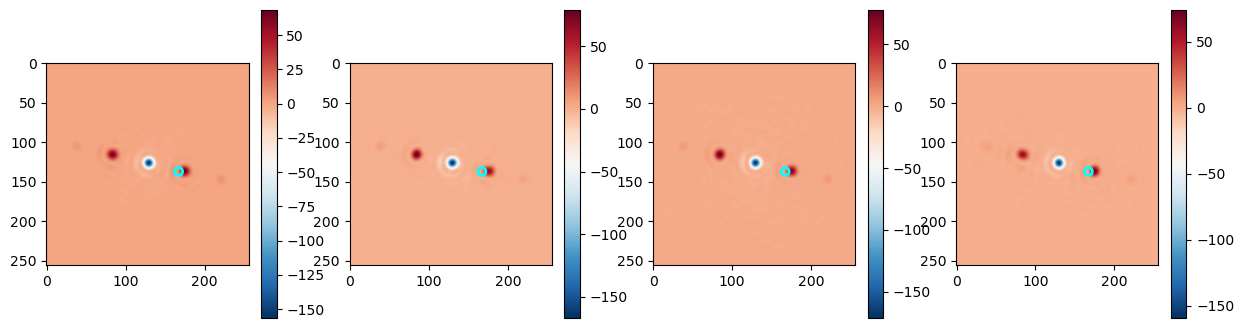

In [20]:
plt.figure(figsize=[15,4])
for i, img in enumerate(sensed_imgs):

    plt.subplot(1,4,i+1)
    plt.imshow(np.abs(img)**2 - np.abs(fwd())**2, cmap="RdBu_r")
    plt.colorbar()
    ax = plt.gca()
    circ = Circle((xind, yind), radius=5, color='cyan', fill=False, linewidth=2)
    ax.add_patch(circ)
    
plt.show()

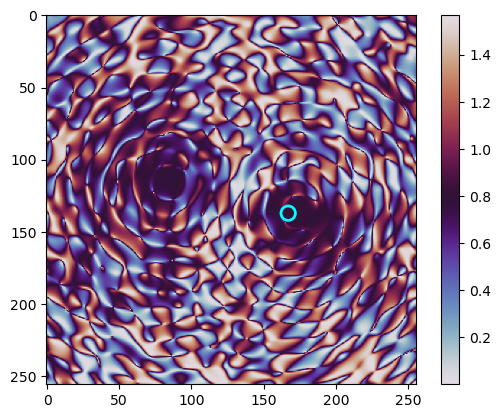

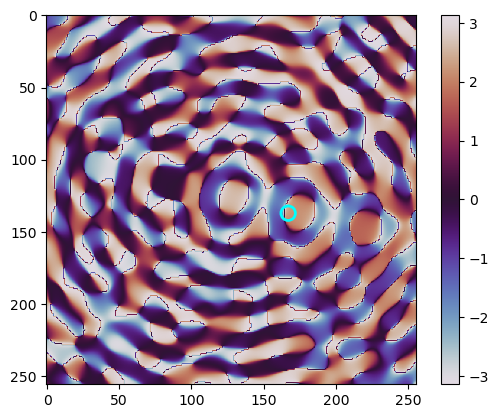

In [21]:
# look at the phase

# Get the phase of the speckle
denominator = sensed_imgs[2] - sensed_imgs[0]
numerator = sensed_imgs[3] - sensed_imgs[1]

phase = np.arctan2(np.abs(numerator)**2, np.abs(denominator)**2)

plt.figure()
plt.imshow(phase, cmap="twilight")
circ = Circle((xind, yind), radius=5, color='cyan', fill=False, linewidth=2)
ax = plt.gca()
ax.add_patch(circ)
plt.colorbar()

plt.figure()
plt.imshow(np.angle(img), cmap="twilight")
circ = Circle((xind, yind), radius=5, color='cyan', fill=False, linewidth=2)
ax = plt.gca()
ax.add_patch(circ)
plt.colorbar()
plt.show()

In [102]:
# Lets try to null the speckle
from tqdm import tqdm

PLOT_IMGS = False
MAX_ITER = 128
contrast_in_dh = []

for i in tqdm(range(MAX_ITER)):

    # First pass at calculations
    if i == 0:
        correction = np.zeros_like(xact)
        dm.actuators[:] = correction

    else:
        dm.actuators[:] = correction

    # current DM state
    dm_influence = A * np.exp(1j * dm.render(wfe=False))
    focal = focus_fixed_sampling(wvfnt * dm_influence,
                            input_dx=Dpup / wvfnt.shape[0], # mm pupil
                            prop_dist=EFL, # mm focal length
                            wavelength=WVL, # microns
                            output_dx=dx_img, # microns
                            output_samples=wvfnt.shape[0])
    
    masked_intensity = np.abs(focal)**2 * dark_hole
    contrast_in_dh.append(np.mean(masked_intensity[dark_hole==1]))

    if PLOT_IMGS:
        plt.figure()
        plt.imshow(masked_intensity, norm=LogNorm(), cmap="inferno")
        plt.colorbar()
        plt.show()
        
    # Identify the maximum in the dark hole region
    yind, xind = np.unravel_index(np.argmax(masked_intensity), masked_intensity.shape)

    # Get the coordinates
    yfreq = u[xind, yind] * (Dpup / WVL) / EFL
    xfreq = v[xind, yind] * (Dpup / WVL) / EFL

    # drop a speckle
    phase_shift = np.arange(0, 2 * np.pi, np.pi/2)
    sensed_imgs = []

    for p in phase_shift:

        # apply phase shift to fourier mode8
        aberration = np.cos(xact*xfreq*4 + yact*yfreq*4 + p) / 4#/ visibility
        dm.actuators[:] = correction + aberration

        # create aberration
        probe = A * np.exp(2 * np.pi / WVL * 1j * dm.render(wfe=False))

        img = fwd(pupil_wfe=probe)
        sensed_imgs.append(np.abs(img)**2)

    I1 = sensed_imgs[0][xind, yind]
    I2 = sensed_imgs[1][xind, yind]
    I3 = sensed_imgs[2][xind, yind]
    I4 = sensed_imgs[3][xind, yind]

    # Get the phase of the speckle
    denominator = I4 - I2
    numerator = I1 - I3

    phase = np.arctan2(numerator, denominator)
    visibility = 2 * np.sqrt(numerator**2 + denominator**2) / (I1 + I2 + I3 + I4)


    
    correction += np.cos(xact*xfreq*4 + yact*yfreq*4 - phase) / 4# / visibility

100%|██████████| 128/128 [00:04<00:00, 31.60it/s]


In [103]:
visibility

0.9846923363409038

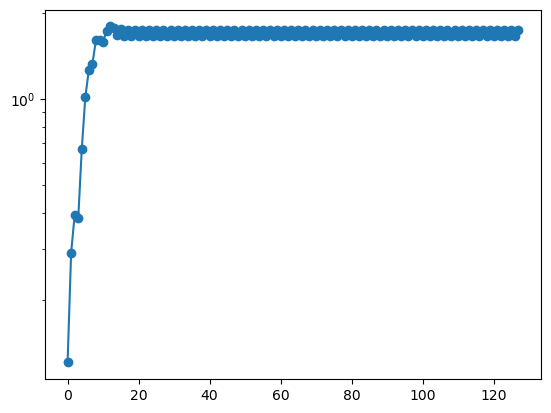

In [104]:
plt.figure()
plt.plot(contrast_in_dh, marker="o")
plt.yscale("log")
plt.show()

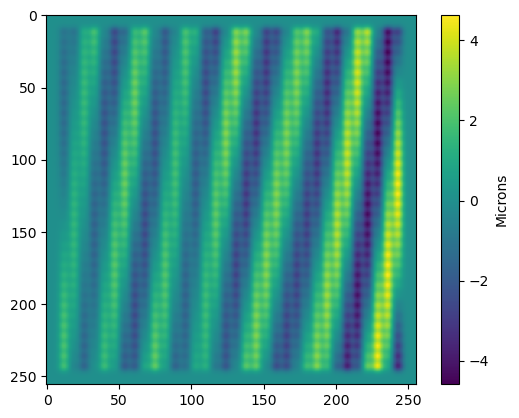

In [105]:
plt.imshow(dm.render())
plt.colorbar(label="Microns")

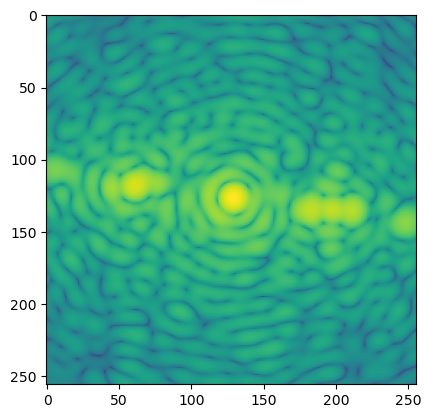

In [106]:
plt.imshow(np.abs(focal)**2 , norm=LogNorm())